# Aggregation of different tables

### Objective of the Notebook: Feature Engineering & Relational Data Consolidation

The objective of this notebook is to build the final training dataset for the credit scoring model by consolidating a complex relational data ecosystem (8 interconnected tables).

#### Technical Challenges:
* **Cardinality Management**: Map and process the various inter-table relationships (one-to-one and one-to-many).
* **Vectorized Aggregation**: Compress transactional and temporal histories (multiple rows) into unified statistical metrics (averages, sums, frequencies) per unique customer using `groupby()`.
* **Structural alignment**: Strategically merge consolidated data to ensure strict row uniqueness (1 row = 1 unique customer) and eliminate any risk of data duplication or data leakage.

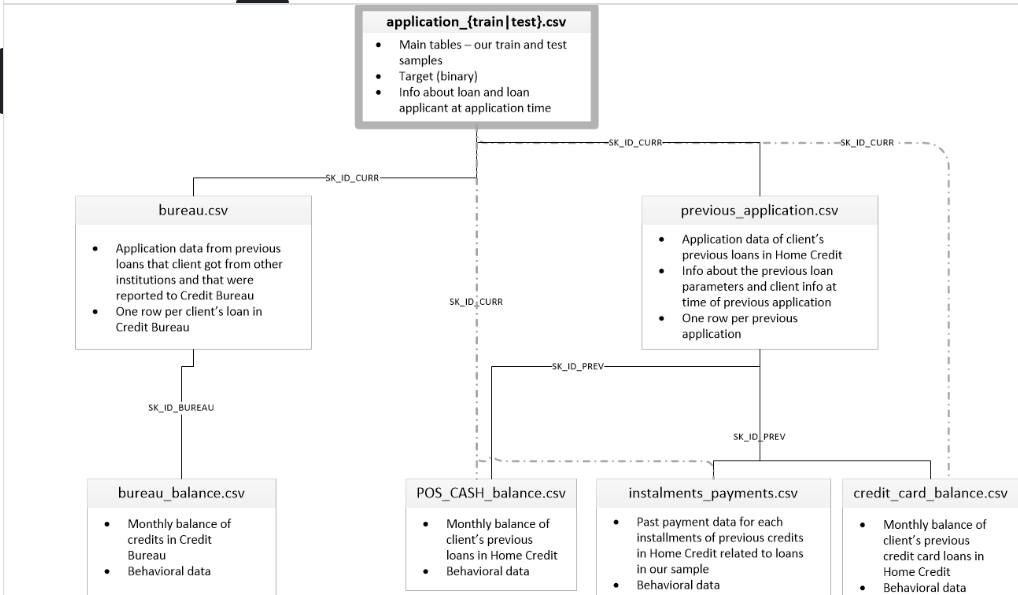

In [1]:
"""src/eda/01_aggregation.ipynb
"""
# Import libraries
import pandas as pd
import numpy as np
import sys
import yaml
from pathlib import Path

# 1. Root path
notebook_dir = Path(".").resolve()
project_root = notebook_dir.parent.parent

# 2. Add to sys.path to allow config import 
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# 3. Import custom logger from config/logging.py
from config.logging import get_logger

# 4. Loading config/config.yaml
config_path = project_root / "config" / "config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# 5. InitializeLogger
logger = get_logger("Exploration-Agg")

# 6. Raw path definition
raw_path = project_root / config["data_paths"]["raw"]

logger.info("Notebook initialized. Project root added to sys.path.")
print(f"Project root: {project_root}")
print(f"Raw data path: {raw_path}")


{"timestamp": "2026-07-15 01:11:34", "level": "INFO", "logger": "Exploration-Agg", "module": "2383575441", "function": "<module>", "message": "Notebook initialized. Project root added to sys.path.", "name": "Exploration-Agg", "msg": "Notebook initialized. Project root added to sys.path.", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_17416\\2383575441.py", "filename": "2383575441.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 32, "funcName": "<module>", "created": 1784070694.1748614, "msecs": 174.0, "relativeCreated": 18337.631464004517, "thread": 10836, "threadName": "MainThread", "processName": "MainProcess", "process": 17416}
Project root: C:\Users\Yves-Ricky\Desktop\credit_project
Raw data path: C:\Users\Yves-Ricky\Desktop\credit_project\data\raw


## Phase 1.1: Aggregation of Bureau & Bureau Balance Tables

### 1. Data Understanding & Relationship
In this section, we process the "External Credit History" of applicants. This data comes from the **Credit Bureau**, providing a view of the client's behavior with other financial institutions.

*   **`bureau.csv`**: Contains one row for every previous credit the client had that was reported to the Credit Bureau. A single client (`SK_ID_CURR`) can have multiple credits.
*   **`bureau_balance.csv`**: Contains the monthly history of those credits. Each row represents one month of a specific credit (`SK_ID_BUREAU`).

### 2. The Challenge: The 1-to-N Relationship
The main difficulty lies in the hierarchical structure:
1.  **1 Client** can have **Multiple Credits** (in `bureau`).
2.  **1 Credit** has **Multiple Months** of history (in `bureau_balance`).

**Our Goal:** We must "flatten" this hierarchy into a single row per client (`SK_ID_CURR`) to join it with our main training table. If we perform a direct join without aggregation, we will duplicate clients and bias the model.

### 3. Aggregation Strategy: The "Bottom-Up" Approach

We follow a 3-step cascade aggregation:

#### Step A: Level 2 - Processing `bureau_balance`
We compress the monthly history into statistics per credit ID (`SK_ID_BUREAU`).
*   **Temporal Logic**: `MONTHS_BALANCE` uses negative values (0 = today, -1 = last month). This allows the model to prioritize recent payment behavior over old history.
*   **Numeric Features**: We calculate the duration (`count`) and the start/end dates (`min`/`max`) of each loan.
*   **Categorical Features**: We apply **One-Hot Encoding** to the `STATUS` column (Closed, Active, DPD) and calculate the **mean**. This generates **"Risk Ratios"** (e.g., a client spent 20% of their time in arrears).

#### Step B: Level 1 - Processing `bureau`
We merge the results from Step A into the `bureau` table and then aggregate everything at the client level (`SK_ID_CURR`).
*   **Feature Engineering**: We encode categorical data like `CREDIT_TYPE` (Credit Card, Consumer Loan) and `CREDIT_ACTIVE`.
*   **Business Ratios**: We calculate the total debt (`sum`), the largest credit ever taken (`max`), and the average number of past loans.

#### Step C: Level 0 - Final Join
The resulting "Client Profile" is joined to the main `application_train` table.

---
**Technical Note on Memory Management:**
Given that `bureau_balance` contains millions of rows, we implement a strict memory cleanup policy using `del` and `gc.collect()` after each merge to prevent kernel crashes.

In [2]:
# 1. Load tables
# We load the full datasets from the raw path defined in config
df_bureau = pd.read_csv(raw_path / config["tables"]["bureau"])
df_bureau_balance = pd.read_csv(raw_path / config["tables"]["bureau_balance"])

In [3]:
import gc # Import garbage collector for memory management

print("Bureau columns: \n", df_bureau.columns)
print("\nBureau Balance columns: \n", df_bureau_balance.columns)
logger.info("Starting Bureau_Balance aggregation by SK_ID_BUREAU...")

# Get the key from config
bureau_key = config["fusion"]["bureau_key"] # "SK_ID_BUREAU"

# 2. Numeric Variables: Calculate history length (count) and most recent month (max)
# Note: MONTHS_BALANCE is negative (0 is current month)
bb_num_agg = df_bureau_balance.groupby(bureau_key).agg(
    bb_MONTHS_COUNT=('MONTHS_BALANCE', 'count'),
    bb_MONTHS_MAX=('MONTHS_BALANCE', 'max'),
    bb_MONTHS_MIN=('MONTHS_BALANCE', 'min') # Useful to know the start of the credit
).reset_index()

# 3. Categorical Variables (STATUS): One-Hot Encoding
# Status indicates if the client is on time (C, 0) or late (1, 2, 3...)
bb_cats = pd.get_dummies(df_bureau_balance[[bureau_key, 'STATUS']], columns=['STATUS'], prefix='bb_status')

# Sum statuses per credit to count how many months the client spent in each state
bb_cat_agg = bb_cats.groupby(bureau_key).sum().reset_index()

# 4. Merge extracts to get a fully compressed bureau_balance table (1 row per credit)
df_bb_aggregated = pd.merge(bb_num_agg, bb_cat_agg, on=bureau_key, how='inner')

# ==========================================================
# MEMORY OPTIMIZATION
# We delete temporary DataFrames that are no longer needed
print(f"Original Shape of bureau_balance : {df_bureau_balance.shape}")
print(f"Shape after aggregation (1 row by credit) : {df_bb_aggregated.shape}")

# Cleanup unused objects from RAM
del df_bureau_balance, bb_num_agg, bb_cat_agg, bb_cats
gc.collect() # Force garbage collection

logger.info("Bureau_Balance aggregation completed and memory cleared.")
df_bb_aggregated.head()

Bureau columns: 
 Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY'],
      dtype='object')

Bureau Balance columns: 
 Index(['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS'], dtype='object')
{"timestamp": "2026-07-15 01:12:13", "level": "INFO", "logger": "Exploration-Agg", "module": "705972778", "function": "<module>", "message": "Starting Bureau_Balance aggregation by SK_ID_BUREAU...", "name": "Exploration-Agg", "msg": "Starting Bureau_Balance aggregation by SK_ID_BUREAU...", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_17416\\705972778.py", "filename": "705972778.py", "exc_info": null, "exc_text

,SK_ID_BUREAU,bb_MONTHS_COUNT,bb_MONTHS_MAX,bb_MONTHS_MIN,bb_status_0,bb_status_1,bb_status_2,bb_status_3,bb_status_4,bb_status_5,bb_status_C,bb_status_X
0,5001709,97,0,-96,0,0,0,0,0,0,86,11
1,5001710,83,0,-82,5,0,0,0,0,0,48,30
2,5001711,4,0,-3,3,0,0,0,0,0,0,1
3,5001712,19,0,-18,10,0,0,0,0,0,9,0
4,5001713,22,0,-21,0,0,0,0,0,0,0,22


**Key Insights from this step:**
* **From 1-N to 1-1**: We collapsed millions of historical records into a unique summary for each `SK_ID_BUREAU`.
* **Risk Ratios**: By calculating the `mean` of the Status Dummy variables, we now have "Risk Ratios". For example, a value of `0.2` in a "Late" status column tells the model that the client was in arrears for **20% of the duration** of that specific loan.
* **Feature Compression**: The shape changed from millions of rows to a significantly smaller dataset, making it ready to be joined with the main `bureau.csv` table.

**Next Step:** Merging this summary with the `bureau.csv` table to link external credit history with the client's main profile.

In [4]:
# ==========================================================
# STEP 1: MERGE BUREAU AND BALANCE SUMMARY
# ==========================================================
# Join the aggregated balance history to each loan in the bureau table
df_bureau = df_bureau.merge(df_bb_aggregated, on='SK_ID_BUREAU', how='left')

# Free RAM immediately
del df_bb_aggregated
gc.collect()

# ==========================================================
# STEP 2: CATEGORICAL ENCODING & AGGREGATION RULES
# ==========================================================
# 1. One-Hot Encoding for categorical features
df_bureau = pd.get_dummies(df_bureau, columns=['CREDIT_ACTIVE', 'CREDIT_TYPE'], prefix='bu')

# 2. Define numeric aggregation rules
agg_rules = {
    'DAYS_CREDIT': ['min', 'max', 'mean'],
    'AMT_CREDIT_SUM': ['sum', 'mean', 'max'],
    'AMT_CREDIT_SUM_DEBT': ['sum', 'mean', 'max'],
}

# 3. Automatically add 'mean' to all new dummy columns (ratios)
dummy_cols = [col for col in df_bureau.columns if col.startswith('bu_')]
agg_rules.update({col: ['mean'] for col in dummy_cols})

# ==========================================================
# STEP 3: FINAL CLIENT-LEVEL AGGREGATION
# ==========================================================
# Compress everything to 1 row per client (SK_ID_CURR)
df_bureau_final = df_bureau.groupby('SK_ID_CURR').agg(agg_rules)

# Flatten MultiIndex column names (e.g., DAYS_CREDIT_MEAN)
df_bureau_final.columns = ['_'.join(col).upper() for col in df_bureau_final.columns]
df_bureau_final = df_bureau_final.reset_index()

# Clean up memory
del df_bureau
gc.collect()

logger.info(f"Bureau branch fully aggregated. Final shape: {df_bureau_final.shape}")
print("-" * 30)
print(f"BUREAU FINAL SUMMARY")
print("-" * 30)
print(f"Total Unique Borrowers (Rows): {df_bureau_final.shape[0]:,}")
print(f"Total Features Created (Cols): {df_bureau_final.shape[1]}")
print("-" * 30)
df_bureau_final.head()

{"timestamp": "2026-07-15 01:13:00", "level": "INFO", "logger": "Exploration-Agg", "module": "3497217109", "function": "<module>", "message": "Bureau branch fully aggregated. Final shape: (305811, 29)", "name": "Exploration-Agg", "msg": "Bureau branch fully aggregated. Final shape: (305811, 29)", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_17416\\3497217109.py", "filename": "3497217109.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 42, "funcName": "<module>", "created": 1784070780.6248686, "msecs": 624.0, "relativeCreated": 104787.6386642456, "thread": 10836, "threadName": "MainThread", "processName": "MainProcess", "process": 17416}
------------------------------
BUREAU FINAL SUMMARY
------------------------------
Total Unique Borrowers (Rows): 305,811
Total Features Created (Cols): 29
------------------------------


,SK_ID_CURR,DAYS_CREDIT_MIN,DAYS_CREDIT_MAX,DAYS_CREDIT_MEAN,AMT_CREDIT_SUM_SUM,AMT_CREDIT_SUM_MEAN,AMT_CREDIT_SUM_MAX,AMT_CREDIT_SUM_DEBT_SUM,AMT_CREDIT_SUM_DEBT_MEAN,AMT_CREDIT_SUM_DEBT_MAX,...,BU_INTERBANK CREDIT_MEAN,BU_LOAN FOR BUSINESS DEVELOPMENT_MEAN,BU_LOAN FOR PURCHASE OF SHARES (MARGIN LENDING)_MEAN,BU_LOAN FOR THE PURCHASE OF EQUIPMENT_MEAN,BU_LOAN FOR WORKING CAPITAL REPLENISHMENT_MEAN,BU_MICROLOAN_MEAN,BU_MOBILE OPERATOR LOAN_MEAN,BU_MORTGAGE_MEAN,BU_REAL ESTATE LOAN_MEAN,BU_UNKNOWN TYPE OF LOAN_MEAN
0,100001,-1572,-49,-735.000000,1453365.000,207623.571429,378000.0,596686.5,85240.928571,373239.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100002,-1437,-103,-874.000000,865055.565,108131.945625,450000.0,245781.0,49156.200000,245781.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100003,-2586,-606,-1400.750000,1017400.500,254350.125000,810000.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100004,-1326,-408,-867.000000,189037.800,94518.900000,94537.8,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100005,-373,-62,-190.666667,657126.000,219042.000000,568800.0,568408.5,189469.500000,543087.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
#Columns
df_bureau_final.columns

Index(['SK_ID_CURR', 'DAYS_CREDIT_MIN', 'DAYS_CREDIT_MAX', 'DAYS_CREDIT_MEAN',
       'AMT_CREDIT_SUM_SUM', 'AMT_CREDIT_SUM_MEAN', 'AMT_CREDIT_SUM_MAX',
       'AMT_CREDIT_SUM_DEBT_SUM', 'AMT_CREDIT_SUM_DEBT_MEAN',
       'AMT_CREDIT_SUM_DEBT_MAX', 'BU_ACTIVE_MEAN', 'BU_BAD DEBT_MEAN',
       'BU_CLOSED_MEAN', 'BU_SOLD_MEAN', 'BU_ANOTHER TYPE OF LOAN_MEAN',
       'BU_CAR LOAN_MEAN', 'BU_CASH LOAN (NON-EARMARKED)_MEAN',
       'BU_CONSUMER CREDIT_MEAN', 'BU_CREDIT CARD_MEAN',
       'BU_INTERBANK CREDIT_MEAN', 'BU_LOAN FOR BUSINESS DEVELOPMENT_MEAN',
       'BU_LOAN FOR PURCHASE OF SHARES (MARGIN LENDING)_MEAN',
       'BU_LOAN FOR THE PURCHASE OF EQUIPMENT_MEAN',
       'BU_LOAN FOR WORKING CAPITAL REPLENISHMENT_MEAN', 'BU_MICROLOAN_MEAN',
       'BU_MOBILE OPERATOR LOAN_MEAN', 'BU_MORTGAGE_MEAN',
       'BU_REAL ESTATE LOAN_MEAN', 'BU_UNKNOWN TYPE OF LOAN_MEAN'],
      dtype='object')

## Phase 1.2: Internal History (Previous Applications & Payments)

In this section, we analyze the client's **internal history with Home Credit**. Unlike the Bureau data (external), this branch contains high-granularity information about every loan the client has previously requested and managed within our institution.

### 1. Data Structure & Relationships
This branch follows a "Hub-and-Spoke" model where `previous_application.csv` acts as the central pivot.

*   **`previous_application.csv` (The Hub)**: Contains one row for every previous loan application made by the client at Home Credit. It includes data on whether the loan was approved, refused, or canceled, as well as the requested amounts and interest rates.
*   **`installments_payments.csv` (Execution)**: Tracks the actual repayment history. Each row is a payment made (or missed). It is the most predictive table for identifying payment behavior (delays or underpayments).
*   **`POS_CASH_balance.csv` (Monthly Status)**: Monthly snapshots of consumer loans or cash loans. It tracks the status of the loan and any potential "Days Past Due" (DPD).
*   **`credit_card_balance.csv` (Monthly Status)**: Specific monthly snapshots for credit cards, tracking credit limit utilization, balance evolution, and ATM drawings.

### 2. Analytical Strategy
Because a client can have multiple previous applications, and each application has multiple monthly records or payments, we must follow a **double aggregation** process:

1.  **Level 2 Aggregation**: Compress the three detail tables (`installments`, `POS`, `credit_card`) by **`SK_ID_PREV`** (Loan ID). At this stage, we create behavioral features like:
    *   **DPD (Days Past Due)**: To capture late payments.
    *   **DBD (Days Before Due)**: To identify "good" payers who pay in advance.
    *   **Payment Gaps**: Differences between the expected installment and the actual amount paid.
2.  **Joining the Hub**: Merge these summaries into the central `previous_application` table.
3.  **Level 1 Aggregation**: Compress the enriched Hub by **`SK_ID_CURR`** (Client ID) to create a final "Internal Portrait" of the borrower.

### 3. Handling Missing Information (XNA/XAP)
Special attention is given to "Placeholder" values like `XNA` (Not Available) and `XAP` (Not Applicable). These are replaced by `np.nan` to ensure our statistical aggregations (mean, sum) are not biased by categorical strings and to allow the Gradient Boosting models to handle the missingness natively.

In [6]:
# Previous_applications table
# 1. Load the table
logger.info("Loading Previous Application table...")
df_prev = pd.read_csv(raw_path / config["tables"]["previous_application"])
print(df_prev.columns)
print("shape before feature_engineering", df_prev.shape)
print("\n missings before enfineering:", df_prev.isnull().sum().sort_values(ascending=False))

# 2. One-Hot Encoding for categorical features
# We focus on the most important ones for the Risk
prev_cat_cols = ['NAME_CONTRACT_TYPE', 'NAME_CONTRACT_STATUS', 'NAME_PAYMENT_TYPE', 
                 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_PRODUCT_TYPE']

logger.info("Encoding categorical features for Previous Applications...")
df_prev = pd.get_dummies(df_prev, columns=prev_cat_cols, prefix='prev')

# 3. Quick Clean: Replace 'XNA' or 'XAP' (custom missing values in this table)
""""
* XNA= X - Not Available
==> for columns like NAME_TYPE_SUITE (who was with the client at the time of the request)

XAP= X - Not Applicable
==> for columns like CODE_REJECT_REASON
If the loan has been approved, there is no reason for rejection. The system therefore enters XAP
"""
df_prev.replace(['XNA', 'XAP'], np.nan, inplace=True)

logger.info(f"Previous Application prepared. Shape: {df_prev.shape}")
print("\n missings after enfineering:", df_prev.isnull().sum().sort_values(ascending=False))
print("shape after feature_engineering", df_prev.shape)
# df_prev columns
df_prev.columns

{"timestamp": "2026-07-15 01:13:00", "level": "INFO", "logger": "Exploration-Agg", "module": "2524397850", "function": "<module>", "message": "Loading Previous Application table...", "name": "Exploration-Agg", "msg": "Loading Previous Application table...", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_17416\\2524397850.py", "filename": "2524397850.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 3, "funcName": "<module>", "created": 1784070780.8738635, "msecs": 873.0, "relativeCreated": 105036.63349151611, "thread": 10836, "threadName": "MainThread", "processName": "MainProcess", "process": 17416}
Index(['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY',
       'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY',
       'RATE_DOWN_PAYME

Index(['SK_ID_PREV', 'SK_ID_CURR', 'AMT_ANNUITY', 'AMT_APPLICATION',
       'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY',
       'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE', 'DAYS_DECISION',
       'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO',
       'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY',
       'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION',
       'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
       'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL',
       'prev_Cash loans', 'prev_Consumer loans', 'prev_Revolving loans',
       'prev_XNA', 'prev_Approved', 'prev_Canceled', 'prev_Refused',
       'prev_Unused offer', 'prev_Cash through the bank',
       'prev_Cashless from the account of the employer',
      

In [7]:
import gc

# ==========================================================
# 1. INSTALLMENTS PAYMENTS (Level 2 Aggregation)
# ==========================================================
logger.info("Processing Installments Payments...")
df_inst = pd.read_csv(raw_path / config["tables"]["installments_payments"])

print(f"\n[1] INSTALLMENTS - Initial Shape: {df_inst.shape}")

# Feature Engineering: Delay (positive = late) and Amount gap
# We create these because a delay in payment is a strong indicator of default risk.
df_inst['inst_DAYS_DIFF'] = df_inst['DAYS_ENTRY_PAYMENT'] - df_inst['DAYS_INSTALMENT']
df_inst['inst_AMT_DIFF'] = df_inst['AMT_INSTALMENT'] - df_inst['AMT_PAYMENT']

# Aggregate by SK_ID_PREV (Loan ID) to get one summary per past loan
inst_agg = df_inst.groupby('SK_ID_PREV').agg({
    'inst_DAYS_DIFF': ['max', 'mean', 'sum'],
    'inst_AMT_DIFF': ['max', 'mean', 'sum'],
    'AMT_INSTALMENT': ['max', 'mean', 'sum'],
    'AMT_PAYMENT': ['min', 'max', 'mean', 'sum']
})
inst_agg.columns = [f"{col[0]}_{col[1]}".upper() for col in inst_agg.columns]

print(f"[1] INSTALLMENTS - Aggregated Shape (by SK_ID_PREV): {inst_agg.shape}")
print(f"[1] INSTALLMENTS - New Columns: {list(inst_agg.columns[:5])}...")

del df_inst
gc.collect()

# ==========================================================
# 2. POS CASH BALANCE (Level 2 Aggregation)
# ==========================================================
logger.info("Processing POS CASH Balance...")
df_pos = pd.read_csv(raw_path / config["tables"]["pos_cash_balance"])

print(f"\n[2] POS CASH - Initial Shape: {df_pos.shape}")

# OHE for contract status to see how often the loan was in 'Active' or 'Completed' state
df_pos = pd.get_dummies(df_pos, columns=['NAME_CONTRACT_STATUS'], prefix='pos')

# Aggregate by SK_ID_PREV
pos_agg = df_pos.groupby('SK_ID_PREV').agg({
    'MONTHS_BALANCE': ['max', 'mean', 'size'],
    'SK_DPD': ['max', 'mean'],
    'SK_DPD_DEF': ['max', 'mean'],
    **{col: ['mean'] for col in df_pos.columns if col.startswith('pos_')}
})
pos_agg.columns = [f"{col[0]}_{col[1]}".upper() for col in pos_agg.columns]

print(f"[2] POS CASH - Aggregated Shape (by SK_ID_PREV): {pos_agg.shape}")

del df_pos
gc.collect()

# ==========================================================
# 3. CREDIT CARD BALANCE (Level 2 Aggregation)
# ==========================================================
logger.info("Processing Credit Card Balance...")
df_cc = pd.read_csv(raw_path / config["tables"]["credit_card_balance"])

print(f"\n[3] CREDIT CARD - Initial Shape: {df_cc.shape}")

# OHE for contract status
df_cc = pd.get_dummies(df_cc, columns=['NAME_CONTRACT_STATUS'], prefix='cc')

# Aggregate by SK_ID_PREV
cc_agg = df_cc.groupby('SK_ID_PREV').agg({
    'AMT_BALANCE': ['max', 'mean', 'sum'],
    'AMT_CREDIT_LIMIT_ACTUAL': ['max', 'mean'],
    'SK_DPD': ['max', 'mean'],
    **{col: ['mean'] for col in df_cc.columns if col.startswith('cc_')}
})
cc_agg.columns = [f"{col[0]}_{col[1]}".upper() for col in cc_agg.columns]

print(f"[3] CREDIT CARD - Aggregated Shape (by SK_ID_PREV): {cc_agg.shape}")

del df_cc
gc.collect()

# ==========================================================
# 4. JOIN SUB-TABLES TO HUB (df_prev)
# ==========================================================
logger.info("Merging Level 2 summaries into df_prev Hub...")
print(f"\n[4] HUB MERGE - df_prev Shape BEFORE Merge: {df_prev.shape}")

df_prev = df_prev.merge(inst_agg, on='SK_ID_PREV', how='left')
df_prev = df_prev.merge(pos_agg, on='SK_ID_PREV', how='left')
df_prev = df_prev.merge(cc_agg, on='SK_ID_PREV', how='left')

print(f"[4] HUB MERGE - df_prev Shape AFTER Merge: {df_prev.shape}")

del inst_agg, pos_agg, cc_agg
gc.collect()

# ==========================================================
# 5. FINAL AGGREGATION TO CLIENT LEVEL (SK_ID_CURR)
# ==========================================================
logger.info("Starting final aggregation to Client level (SK_ID_CURR)...")

# CRITICAL: Select ONLY numeric columns to avoid the 'no attribute name' error.
# This step ensures that categorical strings left in the table don't crash the aggregation.
num_cols = df_prev.select_dtypes(include=['number']).columns.tolist()

agg_rules = {}
for col in num_cols:
    if col in ['SK_ID_CURR', 'SK_ID_PREV']: continue
    
    # Define rules: stats for main features, mean (proportions) for everything else.
    if col in ['AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'DAYS_DECISION']:
        agg_rules[col] = ['min', 'max', 'mean']
    else:
        agg_rules[col] = ['mean']

print(f"\n[5] CLIENT AGG - Aggregating {len(agg_rules)} features...")

# Final GroupBy: Collapsing multiple past loans into one record per client.
df_prev_final = df_prev.groupby('SK_ID_CURR').agg(agg_rules)

# Flatten columns with PRV (Previous) prefix
df_prev_final.columns = [f"PRV_{col[0]}_{col[1]}".upper() for col in df_prev_final.columns]
df_prev_final = df_prev_final.reset_index()

del df_prev
gc.collect()

print(f"\n FINAL RESULT - Internal History Branch Processed.")
print(f"Final Shape: {df_prev_final.shape}")
print(f"Sample Features: {list(df_prev_final.columns[1:10])}")

{"timestamp": "2026-07-15 01:13:24", "level": "INFO", "logger": "Exploration-Agg", "module": "52556072", "function": "<module>", "message": "Processing Installments Payments...", "name": "Exploration-Agg", "msg": "Processing Installments Payments...", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_17416\\52556072.py", "filename": "52556072.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 6, "funcName": "<module>", "created": 1784070804.9529357, "msecs": 952.0, "relativeCreated": 129115.70572853088, "thread": 10836, "threadName": "MainThread", "processName": "MainProcess", "process": 17416}

[1] INSTALLMENTS - Initial Shape: (13605401, 8)
[1] INSTALLMENTS - Aggregated Shape (by SK_ID_PREV): (997752, 13)
[1] INSTALLMENTS - New Columns: ['INST_DAYS_DIFF_MAX', 'INST_DAYS_DIFF_MEAN', 'INST_DAYS_DIFF_SUM', 'INST_AMT_DIFF_MAX', 'INST_AMT_DIFF_MEAN']...
{"timestamp": "2026-07-15 01:14:03", "level": "INFO

## Phase 1.3: Main Merge & Final Training Dataset

This is the final step of our data construction phase. We are joining the three specialized "Portraits" we have built into a single Master Table.

### The Three Components:
1.  **Main Application (`df_app`)**: Current loan request data (income, age, family status).
2.  **External History (`df_bureau_final`)**: Summary of client behavior with other banks.
3.  **Internal History (`df_prev_final`)**: Summary of client behavior with Home Credit (past loans, payments, credit cards).

### Strategy:
We perform a **Left Join** on the `SK_ID_CURR` key. 
*   We keep every client from the main `df_app` table.
*   If a client has no external or internal history, the joined columns will be filled with `NaN`. 
*   **XGBoost/LightGBM** will handle these missing values natively, often interpreting "no history" as a specific risk signal.

In [8]:
# ==========================================================
# RELOADING MAIN APPLICATION TABLE
# ==========================================================
if 'df_app' not in locals():
    logger.info("df_app not found in memory. Reloading...")
    df_app = pd.read_csv(raw_path / config["tables"]["application"])
    print(f"Main Application table reloaded. Shape: {df_app.shape}")
else:
    print("df_app is already in memory.")

# ==========================================================
# THE MAIN MERGE
# ==========================================================
logger.info("Merging all branches into the final training dataset...")

print(f"Initial df_app shape: {df_app.shape}")

# 1. Join External History (Bureau)
df_master = df_app.merge(df_bureau_final, on='SK_ID_CURR', how='left')
print(f"Shape after Bureau join: {df_master.shape}")

# 2. Join Internal History (Previous Apps)
df_master = df_master.merge(df_prev_final, on='SK_ID_CURR', how='left')
print(f"Final Master Shape: {df_master.shape}")

# ==========================================================
# FINAL INSPECTION & CLEANUP
# ==========================================================
# Let's see how many features we created in total
total_features = df_master.shape[1] - 2 # Excluding SK_ID_CURR and TARGET
logger.info(f"Master Table created with {total_features} features.")

# Memory Cleanup of individual branch tables
del df_bureau_final, df_prev_final, df_app
gc.collect()

# Quick look at the missing values created by the merge
missing_stats = (df_master.isnull().sum() / len(df_master) * 100).sort_values(ascending=False)
print("\nTop 5 columns with most missing values (%):")
print(missing_stats.head(5))

# ==========================================================
# SAVE TO PARQUET (NEW STEP)
# ==========================================================
# Define the output directory and file path
interim_dir = project_root / config["data_paths"]["interim"]
interim_dir.mkdir(parents=True, exist_ok=True) # Ensure the folder exists
output_file = interim_dir / "df_master_uncleaned.parquet"

logger.info(f"Saving the uncleaned master table to: {output_file}")

# We use snappy compression for a good balance between speed and file size
df_master.to_parquet(output_file, index=False, compression='snappy')

print(f"Success! Master table saved at {output_file}")

df_master.head()

{"timestamp": "2026-07-15 01:14:43", "level": "INFO", "logger": "Exploration-Agg", "module": "477796302", "function": "<module>", "message": "df_app not found in memory. Reloading...", "name": "Exploration-Agg", "msg": "df_app not found in memory. Reloading...", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_17416\\477796302.py", "filename": "477796302.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 5, "funcName": "<module>", "created": 1784070883.582399, "msecs": 582.0, "relativeCreated": 207745.16892433167, "thread": 10836, "threadName": "MainThread", "processName": "MainProcess", "process": 17416}
Main Application table reloaded. Shape: (307511, 122)
{"timestamp": "2026-07-15 01:14:47", "level": "INFO", "logger": "Exploration-Agg", "module": "477796302", "function": "<module>", "message": "Merging all branches into the final training dataset...", "name": "Exploration-Agg", "msg": "Merging all

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PRV_AMT_CREDIT_LIMIT_ACTUAL_MEAN_MEAN,PRV_SK_DPD_MAX_Y_MEAN,PRV_SK_DPD_MEAN_Y_MEAN,PRV_CC_ACTIVE_MEAN_MEAN,PRV_CC_APPROVED_MEAN_MEAN,PRV_CC_COMPLETED_MEAN_MEAN,PRV_CC_DEMAND_MEAN_MEAN,PRV_CC_REFUSED_MEAN_MEAN,PRV_CC_SENT PROPOSAL_MEAN_MEAN,PRV_CC_SIGNED_MEAN_MEAN
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,270000.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Conclusion: Master Table Generation & Data Sparsity Analysis

### 1. Final Execution Summary
The data construction phase is now complete. By implementing a **cascade aggregation strategy**, we have successfully transformed a complex relational database of **7 disparate tables** into a single, unified **Feature Matrix**.

*   **Total Records**: 307,511 (consistent with the original application set).
*   **Feature Expansion**: We increased the feature count from **122 to 222 (+82%)**.
*   **Storage Efficiency**: The final dataset was saved in **Parquet format** with Snappy compression, ensuring high-speed loading for the modeling phase.
---

### 2. Interpretation of Missing Values (Top 5)

The analysis of the missing values reveals a "Sparse Matrix" structure, which is typical and expected in Credit Scoring. Here is the technical breakdown of the top 5 missing columns:

#### A. Interest Rate Sparsity (~98.5% Missing)
*   `PRV_RATE_INTEREST_PRIVILEGED_MEAN`
*   `PRV_RATE_INTEREST_PRIMARY_MEAN`
*   **Interpretation**: These features refer to specific promotional or internal interest rates. The extreme sparsity indicates that these rates are **highly exceptional** (e.g., loans for employees or specific high-net-worth segments). 
*   **Action**: These columns may be dropped later due to near-zero variance, unless the "presence" of a value acts as a strong indicator of a "privileged" client profile.

#### B. Credit Card & Behavioral Sparsity (~74.7% Missing)
*   `PRV_AMT_CREDIT_LIMIT_ACTUAL_MEAN_MEAN`
*   `PRV_SK_DPD_MAX_Y_MEAN`
*   `PRV_AMT_BALANCE_MEAN_MEAN`
*   **Interpretation**: The ~75% missing rate here is a **logical signal**, not a data quality issue. These columns come from the `credit_card_balance` table. This means that **75% of our current applicants did not have a previous credit card account** with Home Credit. Only ~25% of the population has a revolving credit history.
*   **The "No Data is Data" Principle**: In banking, the absence of history is a feature in itself. Our future models (XGBoost/LightGBM) will interpret these `NaN` values to distinguish between "New Customers" and "Returning Customers with Credit Card History."
---

### Next Steps: Scientific EDA
Now that we have our **Master Table**, we will move to the Exploratory Data Analysis to:
1.  **Correlation Profiling**: Identify which of our 222 features are the strongest predictors of default.
2.  **Outlier Detection**: Isolate extreme financial behaviors using Unsupervised techniques (Isolation Forest).
3.  **Feature Selection**: Filter out columns with near-zero variance or excessive missingness that don't provide predictive "Alpha."

* Save the raw data schema

In [10]:
import os
print(os.getcwd())

c:\Users\Yves-Ricky\Desktop\credit_project\src\eda


In [12]:
# Generate the schema for future uses
import pandera as pa
schema_json_path = "../../config/raw_schema.json"

print(f"Raw data contract saved in : {schema_json_path}")

# 1. Raw_data schema
raw_schema = pa.infer_schema(df_master)

# 2. Save the data contract
raw_schema.to_json(schema_json_path)

print(f"Raw data contract saved in : {schema_json_path}")


Raw data contract saved in : ../../config/raw_schema.json
Raw data contract saved in : ../../config/raw_schema.json


c:\Users\Yves-Ricky\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandera\schema_statistics\pandas.py:214: UserWarning: You do not need more than one check out of equal_to (eq), greater_than (gt), less_than (lt), greater_than_or_equal_to (lt), less_than_or_equal_to (le), in_range (between).
  warnings.warn(
